
# Machine Learning Assignment - 1
## Bike Sharing Demand Prediction

### Student: Pankaj Singh Rawat

This notebook answers all assignment questions using:
- Linear Regression
- Polynomial Regression (Degree 2 & 3)
- Ridge Regression
- Lasso Regression


## Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [19]:

df = pd.read_csv('bike_train.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (10450, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5



# Q1. Examine dataset size, missing values, and feature types


In [20]:

print("Missing Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)


Missing Values
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Data Types
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object



### Observations
- Dataset contains 10,450 rows and 12 columns.
- No missing values exist.
- `datetime` must be converted into datetime format.
- `casual` and `registered` create data leakage because:

count = casual + registered

Hence they must be removed.



# Q2. Visualize relationships between key features and target variable


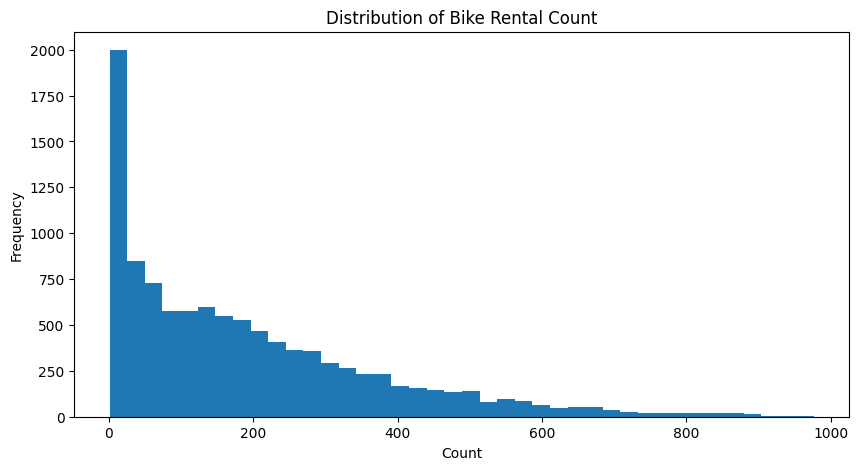

In [21]:

plt.figure(figsize=(10,5))
plt.hist(df['count'], bins=40)
plt.title('Distribution of Bike Rental Count')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()


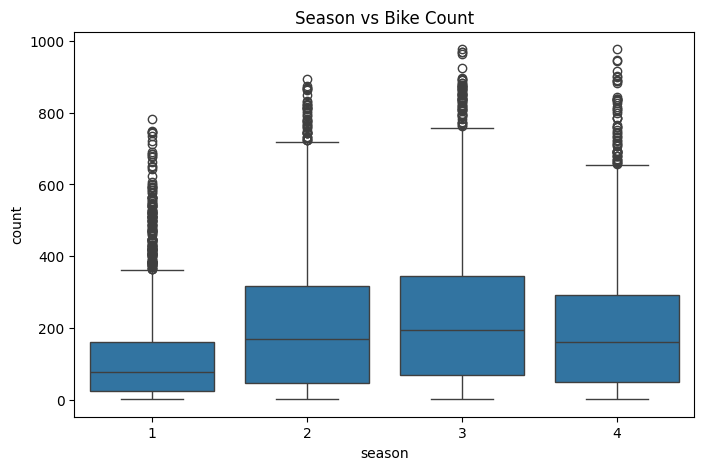

In [22]:

plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='count', data=df)
plt.title('Season vs Bike Count')
plt.show()


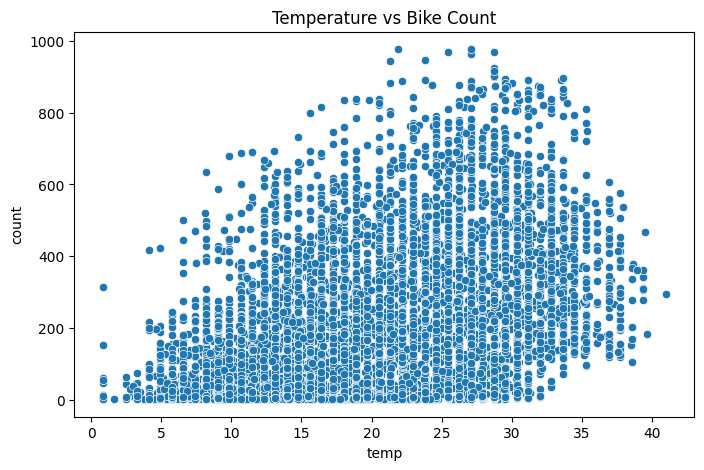

In [23]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='count', data=df)
plt.title('Temperature vs Bike Count')
plt.show()


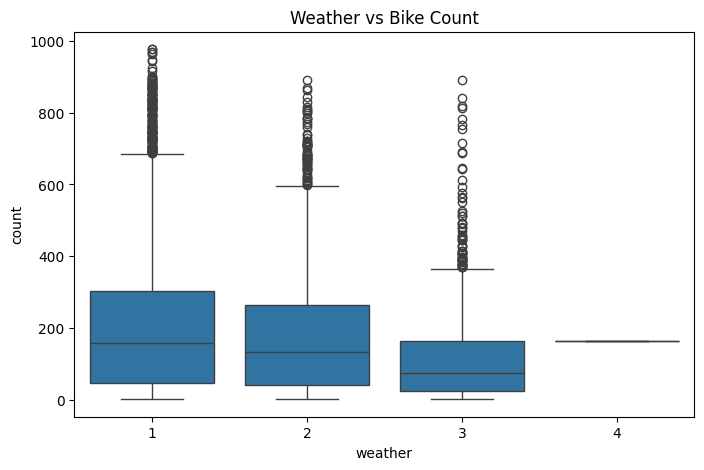

In [24]:

plt.figure(figsize=(8,5))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Weather vs Bike Count')
plt.show()



### Key Findings
- Temperature positively affects rentals.
- Weather conditions impact demand significantly.
- Rentals vary across seasons.
- Demand patterns are highly nonlinear.



# Q3. Suggest which variables are likely to be most informative.



Most informative features:
- hour
- temp
- atemp
- humidity
- weather
- season
- workingday

These variables strongly influence bike rental demand.



# Q4. Feature Engineering


In [25]:

df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['year'] = df['datetime'].dt.year

df_model = df.drop(columns=['datetime', 'casual', 'registered'])

df_model.head()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,weekday,year
0,3,0,0,1,28.70000,33.335000,79,6.003200,47,7,15,7,6,2012
1,3,0,1,1,33.62000,37.880000,46,15.001300,283,15,14,8,1,2012
2,1,0,0,1,10.66000,12.880000,60,15.001300,1,6,6,2,6,2011
3,2,0,0,2,26.42506,30.566166,61,9.512288,531,17,6,5,6,2012
4,1,0,1,1,9.84000,12.120000,56,8.998100,5,2,9,1,0,2012



### Feature Engineering Performed
Features extracted:
- hour
- day
- month
- weekday
- year

These help capture:
- time-of-day patterns
- weekday/weekend behavior
- seasonal trends



# Correlation Heatmap


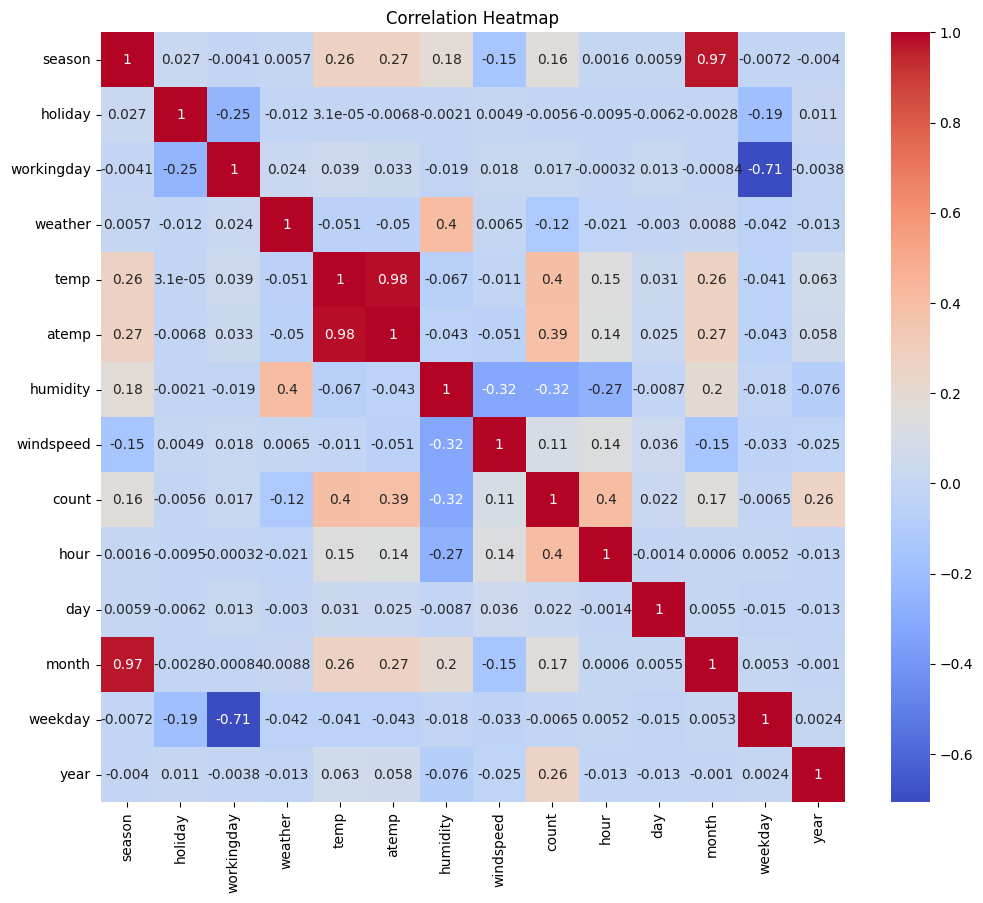

In [26]:

plt.figure(figsize=(12,10))

corr = df_model.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()



# Q5 & Q6. Build Regression Models


In [27]:

X = df_model.drop(columns=['count'])
y = df_model['count']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_val.shape)


(8360, 13)
(2090, 13)


In [28]:

def rmsle(y_true, y_pred):
    
    y_pred = np.maximum(0, y_pred)
    
    return np.sqrt(
        np.mean(
            (np.log1p(y_pred) - np.log1p(y_true))**2
        )
    )


In [29]:

models = {

    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Polynomial Degree 2': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Polynomial Degree 3': Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ]),

    'Lasso Regression': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=10000))
    ])
}


In [30]:

results = []

predictions = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    
    score = rmsle(y_val, preds)
    
    results.append({
        'Model': name,
        'RMSLE': round(score, 5)
    })
    
    predictions[name] = preds

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='RMSLE')

results_df


,Model,RMSLE
2,Polynomial Degree 3,1.20910
0,Linear Regression,1.28695
3,Ridge Regression,1.36157
4,Lasso Regression,1.37133
1,Polynomial Degree 2,1.38575



# Q7. Model Comparison



### Observations
- Lower RMSLE indicates better performance.
- Polynomial models capture nonlinear behavior better.
- Ridge and Lasso help reduce overfitting.



# Q8. Residual Plot for Best Model


Best Model: Polynomial Degree 3


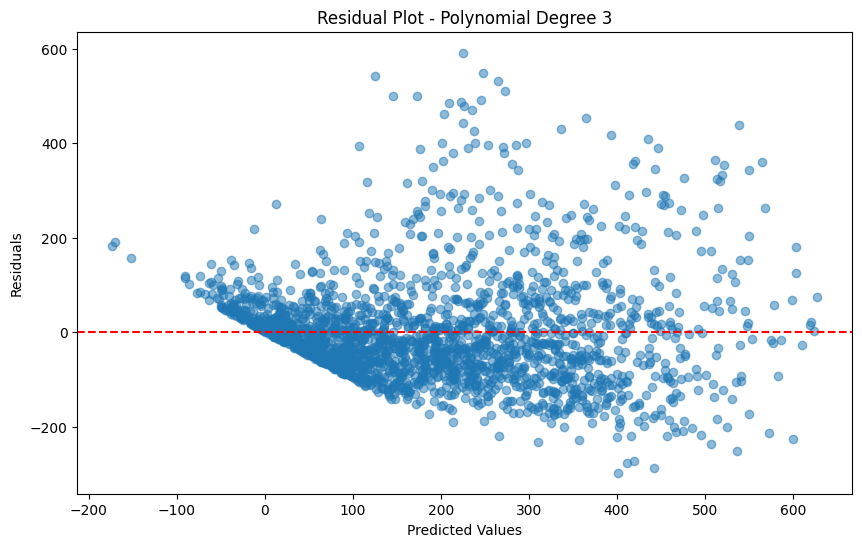

In [31]:

best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

best_preds = predictions[best_model_name]

residuals = y_val - best_preds

plt.figure(figsize=(10,6))

plt.scatter(best_preds, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.title(f'Residual Plot - {best_model_name}')

plt.show()



# Q9. Why Does the Winning Model Perform Better?



The winning model performs better because:
- nonlinear relationships are captured
- feature interactions are learned
- temporal patterns are modeled effectively
- regularization reduces overfitting



# Q10. Why does RMSLE penalize under-predictions more gently than RMSE?



RMSLE uses logarithmic transformation before computing error.

Advantages:
- focuses on relative differences
- reduces impact of large numeric errors
- suitable for demand prediction tasks



# Q11. Trade-offs Between Simplicity and Predictive Power



### Simple Models
Advantages:
- easy interpretation
- fast training

Disadvantages:
- may underfit complex patterns

### Complex Models
Advantages:
- higher accuracy
- captures nonlinear relationships

Disadvantages:
- overfitting risk
- harder interpretation



# Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?



Bike demand changes cyclically:
- morning peak
- afternoon drop
- evening peak

Linear regression assumes a straight-line relationship and therefore cannot model cyclical patterns effectively.



# Final Conclusion

This assignment demonstrates:
- importance of EDA
- feature engineering benefits
- usefulness of polynomial regression
- importance of regularization
- effectiveness of RMSLE for bike demand prediction
